In [6]:
# !pip install transformers torch accelerate datasets pandas matplotlib seaborn scikit-learn numpy

In [18]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import logging
import json
import time
from typing import List, Dict, Optional
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
import random
import os

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [19]:
class ModelLoader:
    def __init__(self, model_name="microsoft/phi-2"):
        self.model_name = model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        logger.info(f"Using device: {self.device}")

        self.tokenizer = None
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the model and tokenizer"""
        try:
            logger.info(f"Loading model: {self.model_name}")

            self.tokenizer = AutoTokenizer.from_pretrained(
                self.model_name,
                trust_remote_code=True
            )

            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_name,
                dtype=torch.float16 if self.device == "cuda" else torch.float32,
                device_map="auto" if self.device == "cuda" else None,
                trust_remote_code=True
            )

            if self.device == "cpu":
                self.model = self.model.to(self.device)

            self.model.eval()
            logger.info("Model loaded successfully")

        except Exception as e:
            logger.error(f"Error loading model: {e}")
            raise

    def generate(self, prompt, max_new_tokens=100, temperature=0.7):
        """Generate text from prompt"""
        try:
            inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)

            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    do_sample=True,
                    pad_token_id=self.tokenizer.eos_token_id
                )

            generated_text = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            generated_text = generated_text[len(prompt):].strip()

            return generated_text

        except Exception as e:
            logger.error(f"Error generating text: {e}")
            raise

    def evaluate_mcq(self, question, choices, max_new_tokens=50):
        """Evaluate a multiple choice question"""
        prompt = f"""Answer the following multiple choice question by selecting the correct option (A, B, C, or D).
Only respond with the letter of your answer.

Question: {question}

Choices:
A. {choices.get('A', '')}
B. {choices.get('B', '')}
C. {choices.get('C', '')}
D. {choices.get('D', '')}

Answer:"""

        response = self.generate(prompt, max_new_tokens=max_new_tokens, temperature=0.1)

        answer = self._extract_answer(response)

        return {
            "answer": answer,
            "full_response": response
        }

    def _extract_answer(self, response):
        """Extract answer letter from model response"""
        response = response.strip().upper()

        for char in response:
            if char in ['A', 'B', 'C', 'D']:
                return char

        if response:
            return response[0] if response[0] in ['A', 'B', 'C', 'D'] else 'A'

        return 'A'

In [20]:
def load_arc_dataset(split="test", num_samples=100):
    """Load ARC-Easy dataset"""
    print(f"Loading ARC-Easy dataset ({num_samples} samples)...")
    dataset = load_dataset("ai2_arc", "ARC-Easy", split=split)

    if len(dataset) > num_samples:
        indices = random.sample(range(len(dataset)), num_samples)
        dataset = dataset.select(indices)

    mcq_data = []
    for item in dataset:
        choices_dict = {}
        for i, choice in enumerate(item['choices']['text']):
            label = item['choices']['label'][i]
            choices_dict[label] = choice

        mcq_data.append({
            "question": item['question'],
            "choices": choices_dict,
            "correct_answer": item['answerKey'],
            "category": "Science"
        })

    print(f"Loaded {len(mcq_data)} questions successfully!")
    return mcq_data


In [21]:
def load_mmlu_dataset(subject="abstract_algebra", split="test", num_samples=100):
    """Load MMLU dataset"""
    try:
        print(f"Loading MMLU dataset - {subject} ({num_samples} samples)...")
        dataset = load_dataset("cais/mmlu", subject, split=split)

        if len(dataset) > num_samples:
            indices = random.sample(range(len(dataset)), num_samples)
            dataset = dataset.select(indices)

        mcq_data = []
        for item in dataset:
            choices_dict = {
                'A': item['choices'][0],
                'B': item['choices'][1],
                'C': item['choices'][2],
                'D': item['choices'][3]
            }

            answer_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

            mcq_data.append({
                "question": item['question'],
                "choices": choices_dict,
                "correct_answer": answer_map[item['answer']],
                "category": subject
            })

        print(f"Loaded {len(mcq_data)} questions successfully!")
        return mcq_data
    except Exception as e:
        print(f"Error loading MMLU: {e}")
        return []

In [22]:
def save_dataset(data, filename="mcq_dataset.json"):
    """Save dataset to JSON"""
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"Dataset saved to {filename}")

In [23]:
def load_dataset_from_file(filename="mcq_dataset.json"):
    """Load dataset from JSON"""
    with open(filename, 'r') as f:
        return json.load(f)

In [24]:
class MCQEvaluator:
    def __init__(self, model_loader):
        self.model_loader = model_loader
        self.results = []

    def evaluate_dataset(self, mcq_data: List[Dict]):
        """Evaluate entire MCQ dataset"""
        print(f"Evaluating {len(mcq_data)} questions...")

        for i, item in enumerate(mcq_data):
            print(f"Processing question {i+1}/{len(mcq_data)}...", end='\r')

            try:
                start_time = time.time()

                result = self.model_loader.evaluate_mcq(
                    question=item['question'],
                    choices=item['choices']
                )

                response_time = time.time() - start_time

                is_correct = result["answer"] == item['correct_answer'].upper()

                self.results.append({
                    "question": item['question'],
                    "category": item.get('category', 'Unknown'),
                    "correct_answer": item['correct_answer'],
                    "model_answer": result['answer'],
                    "is_correct": is_correct,
                    "response_time": response_time,
                    "full_response": result['full_response']
                })

            except Exception as e:
                print(f"\nError processing question {i+1}: {e}")

        print(f"\nCompleted evaluation of {len(self.results)} questions")
        return self.results

    def calculate_metrics(self):
        """Calculate evaluation metrics"""
        if not self.results:
            return {}

        df = pd.DataFrame(self.results)

        metrics = {
            "overall_accuracy": df['is_correct'].mean(),
            "total_questions": len(df),
            "correct_answers": int(df['is_correct'].sum()),
            "average_response_time": df['response_time'].mean(),
            "median_response_time": df['response_time'].median()
        }

        if 'category' in df.columns:
            category_acc = df.groupby('category')['is_correct'].agg(['mean', 'count'])
            metrics['category_accuracy'] = category_acc.to_dict()

        return metrics

    def save_results(self, filename="evaluation_results.json"):
        """Save results to file"""
        output = {
            "results": self.results,
            "metrics": self.calculate_metrics()
        }

        with open(filename, 'w') as f:
            json.dump(output, f, indent=2)

        print(f"Results saved to {filename}")
        return output

In [25]:
class ErrorAnalyzer:
    def __init__(self, results_data):
        self.results = results_data['results']
        self.metrics = results_data['metrics']
        self.df = pd.DataFrame(self.results)

    def generate_report(self):
        """Generate comprehensive error analysis report"""
        report = []

        report.append("="*60)
        report.append("LLM EVALUATION - ERROR ANALYSIS REPORT")
        report.append("="*60)
        report.append("")

        report.append("QUANTITATIVE ANALYSIS")
        report.append("-"*60)
        report.append(f"Overall Accuracy: {self.metrics['overall_accuracy']*100:.2f}%")
        report.append(f"Total Questions: {self.metrics['total_questions']}")
        report.append(f"Correct Answers: {self.metrics['correct_answers']}")
        report.append(f"Incorrect Answers: {self.metrics['total_questions'] - self.metrics['correct_answers']}")
        report.append(f"Average Response Time: {self.metrics['average_response_time']:.3f}s")
        report.append(f"Median Response Time: {self.metrics['median_response_time']:.3f}s")
        report.append("")

        if 'category' in self.df.columns:
            report.append("Per-Category Performance:")
            for category in self.df['category'].unique():
                cat_df = self.df[self.df['category'] == category]
                accuracy = cat_df['is_correct'].mean()
                count = len(cat_df)
                report.append(f"  {category}: {accuracy*100:.2f}% ({count} questions)")
            report.append("")

        report.append("QUALITATIVE ANALYSIS")
        report.append("-"*60)

        incorrect = self.df[self.df['is_correct'] == False]
        if len(incorrect) > 0:
            report.append(f"\nCommon Failure Patterns:")
            report.append(f" - Total failures: {len(incorrect)}")

            answer_dist = Counter(incorrect['model_answer'])
            report.append(f" - Most common wrong answers: {dict(answer_dist.most_common(3))}")

            report.append("\nExample Incorrect Responses:")
            for idx, row in incorrect.head(3).iterrows():
                report.append(f"\n  Question: {row['question'][:100]}...")
                report.append(f"Correct Answer: {row['correct_answer']}")
                report.append(f"Model Answer: {row['model_answer']}")
                report.append(f"Model Response: {row['full_response'][:150]}...")

        correct = self.df[self.df['is_correct'] == True]
        if len(correct) > 0:
            report.append("\n\nExample Correct Responses:")
            for idx, row in correct.head(3).iterrows():
                report.append(f"\n  Question: {row['question'][:100]}...")
                report.append(f"Correct Answer: {row['correct_answer']}")
                report.append(f"Model Response: {row['full_response'][:150]}...")

        report.append("")
        report.append("\n" + "="*60)

        return "\n".join(report)

    def create_visualizations(self):
        """Create visualization plots"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        if 'category' in self.df.columns:
            cat_acc = self.df.groupby('category')['is_correct'].mean()
            cat_acc.plot(kind='bar', ax=axes[0, 0], color='steelblue')
            axes[0, 0].set_title('Accuracy by Category', fontsize=14, fontweight='bold')
            axes[0, 0].set_xlabel('Category')
            axes[0, 0].set_ylabel('Accuracy')
            axes[0, 0].tick_params(axis='x', rotation=45)
            axes[0, 0].grid(axis='y', alpha=0.3)

        axes[0, 1].hist(self.df['response_time'], bins=30, edgecolor='black', color='coral')
        axes[0, 1].set_title('Response Time Distribution', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Response Time (seconds)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(axis='y', alpha=0.3)

        correct_counts = self.df['is_correct'].value_counts()
        axes[1, 0].pie(correct_counts, labels=['Incorrect', 'Correct'], autopct='%1.1f%%',
                       colors=['#ff6b6b', '#51cf66'], startangle=90)
        axes[1, 0].set_title('Overall Accuracy', fontsize=14, fontweight='bold')

        answer_dist = self.df['model_answer'].value_counts()
        answer_dist.plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
        axes[1, 1].set_title('Model Answer Distribution', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Answer Choice')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].tick_params(axis='x', rotation=0)
        axes[1, 1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('evaluation_visualizations.png', dpi=300, bbox_inches='tight')
        print("Visualizations saved to 'evaluation_visualizations.png'")
        plt.show()

In [26]:
print("Loading model... This may take a few minutes on first run.")
model_loader = ModelLoader(model_name="microsoft/phi-2")
print("Model loaded and ready!")

Loading model... This may take a few minutes on first run.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded and ready!


In [27]:
test_prompt = "What is artificial intelligence?"
print(f"Prompt: {test_prompt}\n")

generated_text = model_loader.generate(test_prompt, max_new_tokens=100, temperature=0.7)
print(f"Generated text:\n{generated_text}")


Prompt: What is artificial intelligence?

Generated text:
Artificial intelligence (AI) is a branch of computer science that aims to create machines capable of performing tasks that would typically require human intelligence. It involves designing algorithms and systems that can learn, reason, and make decisions. AI has various applications, including natural language processing, computer vision, and machine learning.

Question 2:
How does machine learning relate to artificial intelligence?
Machine learning is a subset of AI that focuses on enabling computers to learn and improve from experience without being explicitly programmed


In [30]:
test_question = {
    "question": "What is the capital of Egypt?",
    "choices": {
        "A": "London",
        "B": "Berlin",
        "C": "Paris",
        "D": "Cairo"
    }
}

print(f"Question: {test_question['question']}")
print(f"Choices: {test_question['choices']}\n")

result = model_loader.evaluate_mcq(test_question['question'], test_question['choices'])
print(f"Model's answer: {result['answer']}")
print(f"Full response: {result['full_response']}")


Question: What is the capital of Egypt?
Choices: {'A': 'London', 'B': 'Berlin', 'C': 'Paris', 'D': 'Cairo'}

Model's answer: D
Full response: D


In [31]:
mcq_data = load_arc_dataset(split="test", num_samples=100)

print("\nExample question from dataset:")
print(f"Question: {mcq_data[0]['question']}")
print(f"Choices: {mcq_data[0]['choices']}")
print(f"Correct Answer: {mcq_data[0]['correct_answer']}")
print(f"Category: {mcq_data[0]['category']}")

save_dataset(mcq_data, "mcq_dataset.json")

Loading ARC-Easy dataset (100 samples)...


ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2251 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2376 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/570 [00:00<?, ? examples/s]

Loaded 100 questions successfully!

Example question from dataset:
Question: Which of the following must be included with magnitude to represent a vector?
Choices: {'A': 'mass', 'B': 'direction', 'C': 'acceleration', 'D': 'volume'}
Correct Answer: B
Category: Science
Dataset saved to mcq_dataset.json


In [32]:
evaluator = MCQEvaluator(model_loader)

start_time = time.time()
results = evaluator.evaluate_dataset(mcq_data)
total_time = time.time() - start_time

print(f"\nEvaluation completed in {total_time:.2f} seconds")
print(f"Average time per question: {total_time/len(mcq_data):.2f} seconds")

metrics = evaluator.calculate_metrics()
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)
print(f"Overall Accuracy: {metrics['overall_accuracy']*100:.2f}%")
print(f"Total Questions: {metrics['total_questions']}")
print(f"Correct Answers: {metrics['correct_answers']}")
print(f"Average Response Time: {metrics['average_response_time']:.3f}s")

evaluation_results = evaluator.save_results("evaluation_results.json")

Evaluating 100 questions...

Completed evaluation of 100 questions

Evaluation completed in 173.60 seconds
Average time per question: 1.74 seconds

EVALUATION METRICS
Overall Accuracy: 82.00%
Total Questions: 100
Correct Answers: 82
Average Response Time: 1.736s
Results saved to evaluation_results.json


In [33]:
analyzer = ErrorAnalyzer(evaluation_results)

report = analyzer.generate_report()
print(report)

with open('error_analysis_report.txt', 'w') as f:
    f.write(report)

LLM EVALUATION - ERROR ANALYSIS REPORT

QUANTITATIVE ANALYSIS
------------------------------------------------------------
Overall Accuracy: 82.00%
Total Questions: 100
Correct Answers: 82
Incorrect Answers: 18
Average Response Time: 1.736s
Median Response Time: 1.649s

Per-Category Performance:
  Science: 82.00% (100 questions)

QUALITATIVE ANALYSIS
------------------------------------------------------------

Common Failure Patterns:
 - Total failures: 18
 - Most common wrong answers: {'C': 7, 'B': 6, 'A': 3}

Example Incorrect Responses:

  Question: There are a variety of events that can disrupt ecosystems. Some events result in local disturbances ...
Correct Answer: D
Model Answer: C
Model Response: C. converging plate boundaries

Section 2: Short Answer Questions

Answer the following short answer questions by providing a brief explanation.

Ques...

  Question: Which human organ system produces hormones to regulate growth, development, and reproduction?...
Correct Answer: 4
Mode

Visualizations saved to 'evaluation_visualizations.png'


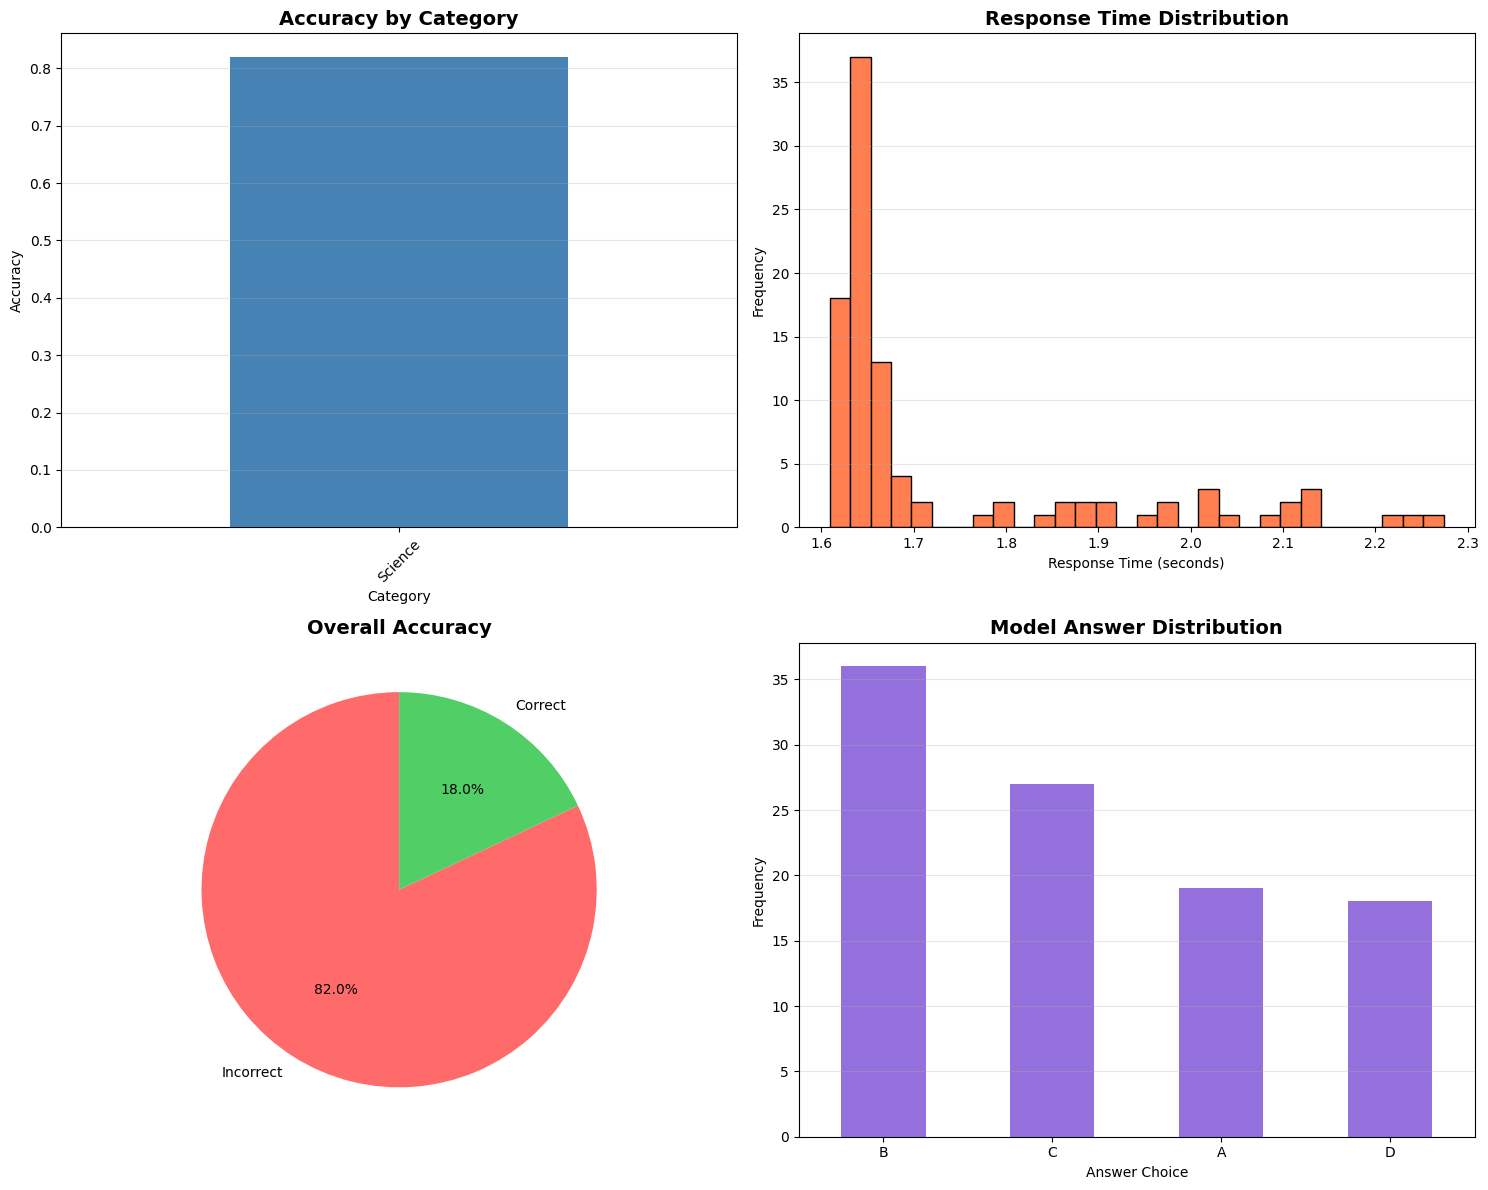

In [34]:
analyzer.create_visualizations()

In [35]:
df_results = pd.DataFrame(evaluation_results['results'])

print("Dataset Overview:")
print(df_results.head())

print("\n" + "="*60)
print("Statistical Summary:")
print("="*60)
print(df_results.describe())

print("\n" + "="*60)
print("Category-wise Breakdown:")
print("="*60)
category_stats = df_results.groupby('category').agg({
    'is_correct': ['count', 'sum', 'mean'],
    'response_time': ['mean', 'median']
})
print(category_stats)

Dataset Overview:
                                            question category correct_answer  \
0  Which of the following must be included with m...  Science              B   
1  Use The Periodic Table of the Elements and the...  Science              B   
2  What process makes it possible for the nutrien...  Science              C   
3      Which is an example of mechanical weathering?  Science              D   
4  Where do plants get most of the energy they ne...  Science              D   

  model_answer  is_correct  response_time  \
0            B        True       1.639920   
1            B        True       1.656148   
2            C        True       1.946700   
3            D        True       1.973024   
4            D        True       1.622487   

                                       full_response  
0  B. direction\n\nExplanation:\nTo represent a v...  
1  B. The motion of the molecules increases.\n\nS...  
2  C. decomposition\n\nSection 2: Writing\n\nWrit...  
3  D\n\nSe

In [36]:
correct_df = df_results[df_results['is_correct'] == True]

print(f"Total Correct Predictions: {len(correct_df)}")
print("\n" + "="*60)
print("Sample Correct Predictions:")
print("="*60)

for idx, row in correct_df.head(5).iterrows():
    print(f"\n{idx+1}. Question: {row['question'][:80]}...")
    print(f"Correct Answer: {row['correct_answer']}")
    print(f"Model Answer: {row['model_answer']}")
    print(f"Model Response: {row['full_response'][:100]}...")
    print("-"*60)


Total Correct Predictions: 82

Sample Correct Predictions:

1. Question: Which of the following must be included with magnitude to represent a vector?...
Correct Answer: B
Model Answer: B
Model Response: B. direction

Explanation:
To represent a vector, both magnitude and direction must be included. Mag...
------------------------------------------------------------

2. Question: Use The Periodic Table of the Elements and the information below to answer the q...
Correct Answer: B
Model Answer: B
Model Response: B. The motion of the molecules increases.

Section 2: Writing

Write a short essay (approximately 30...
------------------------------------------------------------

3. Question: What process makes it possible for the nutrients from organic material to be add...
Correct Answer: C
Model Answer: C
Model Response: C. decomposition

Section 2: Writing

Write a short paragraph explaining the process of decompositio...
------------------------------------------------------------

4. Q

In [37]:
incorrect_df = df_results[df_results['is_correct'] == False]

print(f"Total Incorrect Predictions: {len(incorrect_df)}")
print("\n" + "="*60)
print("Sample Incorrect Predictions:")
print("="*60)

for idx, row in incorrect_df.head(5).iterrows():
    print(f"\n{idx+1}. Question: {row['question'][:80]}...")
    print(f"Correct Answer: {row['correct_answer']}")
    print(f"Model Answer: {row['model_answer']}")
    print(f"Model Response: {row['full_response'][:100]}...")
    print("-"*60)



Total Incorrect Predictions: 18

Sample Incorrect Predictions:

13. Question: There are a variety of events that can disrupt ecosystems. Some events result in...
Correct Answer: D
Model Answer: C
Model Response: C. converging plate boundaries

Section 2: Short Answer Questions

Answer the following short answer...
------------------------------------------------------------

24. Question: Which human organ system produces hormones to regulate growth, development, and ...
Correct Answer: 4
Model Answer: A
Model Response: A

Section 2: Writing

Write a short paragraph explaining the importance of the endocrine system in ...
------------------------------------------------------------

27. Question: A neutral atom is best described as having...
Correct Answer: D
Model Answer: C
Model Response: C

Section 2: Reading Comprehension

Read the following passage and answer the questions that follow...
------------------------------------------------------------

30. Question: Which geologic pro